Search Algorithm - Depth First search, with python

- the search algorithm is an algorithm to retrieve information stored within some data structure, or calculated in the search space of a problem
- A search strategy is defined by picking the order of node expansion. Strategies can be evaluated along the following dimensions..
- Completeness: Does it always find a solution if one exists?
- Time complexity: How long does it take to a find a solution?
- Space Complexity: Maximum number of nodes in memory?
- Optimality: Does it find the best (least-cost) solution?

Definition
- depth first search is an algorithm for traversing or searching tree or graph data structure. Before explaining the DFS algorithm, let's introduce the graph data structure. A graph G is a pair (V,E), where V is a finite set and E is a set of binary relations on V.
- V is called the vertex set and its elements are vertices
- E is called the edge set and its element are called edges. An edge is represented by a pair of vertices

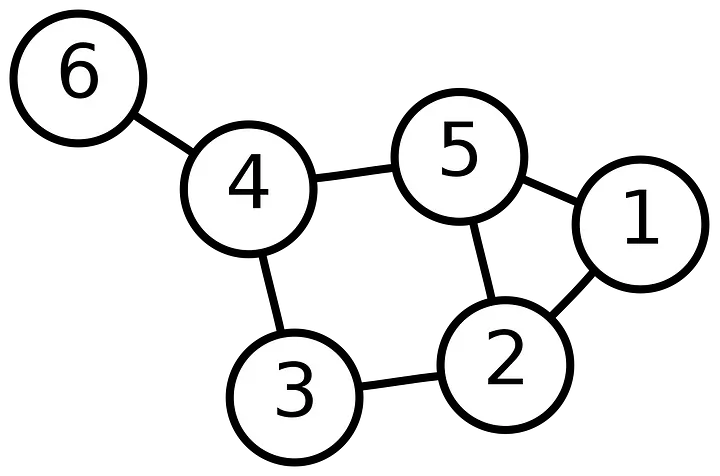

The diagram above is a schematic representation of the graph with vertices 
- v = {1, 2, 3, 4, 5, 6}
- E = {{1,2}, {1,5}, {2, 3}, {2,5}, {3,4}, {4,5}, {4,6}}

Depth-First Search (DFS)
- it starts at the root node and expands to the deepest unexpanded node, backtrack only when no more expansion.


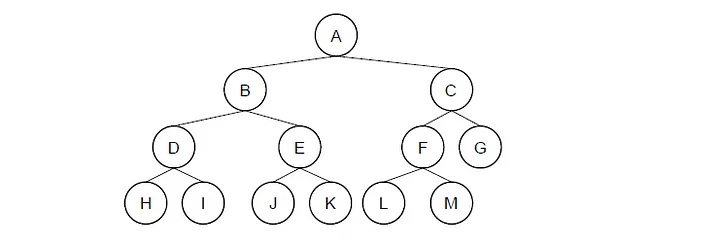 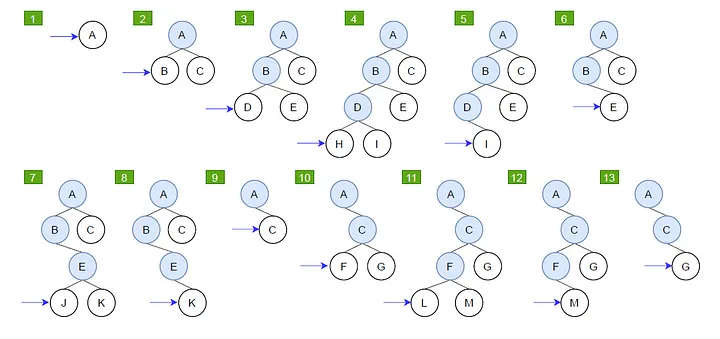


From the above step by step expansion diagram, the DFS algorithm prioritizes edges along the path to perform a search.

To evaluate this algorithm:
- denote m as the maximum depth of the state space and b as the maximum branching factor of the search tree or graph

1. Completenes:
    - infinite-depth spaces: No
    - finite-depth spaces with no loops: No
    - finite-depth spaces with repeated-state-checking: Yes
    - finite-depth spaces without loops: yes.
2. time complexity: O(b^m)
3. space complexity: O(bm)
4. Optimality: No

The diagram is a schematic representation of the graph with:
- vertices V = {A, B, C, D, E, F, G, H, I, J, K, L, M}
- edge set E = {{A,B}, {A, C}, {B, D}, {B, E}, {C, F}, {C, G}, {D, H}, {D, I}, {E, J}, {E, K}, {F, L}, {F,M}}

Creating a function that takes the edges of the graph which outputs the adjacency list for undirected graph

In [3]:
from collections import defaultdict

# generate adjacency list for undirected graph
def generate_adjacency_list(edges):
    adjacencyList = defaultdict(list)
    for u, v in edges:
        adjacencyList[u].append(v)
        adjacencyList[v].append(u)
    return adjacencyList

edges = [['A', 'B'], ['A', 'C'], ['B', 'D'], ['B', 'E'], ['C', 'F'], ['C', 'G'], ['D', 'H'], ['D', 'I'], ['E', 'J'], ['E', 'K'], ['F', 'L'], ['F', 'M']]
adjacencyList = generate_adjacency_list(edges)
print(adjacencyList)

defaultdict(<class 'list'>, {'A': ['B', 'C'], 'B': ['A', 'D', 'E'], 'C': ['A', 'F', 'G'], 'D': ['B', 'H', 'I'], 'E': ['B', 'J', 'K'], 'F': ['C', 'L', 'M'], 'G': ['C'], 'H': ['D'], 'I': ['D'], 'J': ['E'], 'K': ['E'], 'L': ['F'], 'M': ['F']})


Creating the function that takes the adjacency list and starting vertex which output the sequence of DFS search

In [7]:
# find dfs traversal from starting vertex
def dfs(adjacencyList, vertex, visitedSet=None, path=None):
    # create memo once in top-level call
    if visitedSet is None:
        visitedSet = set()
    if path is None:
        path = []
    
    visitedSet.add(vertex)
    path.append(vertex)

    print(visitedSet)
    print(path)
    if(vertex in adjacencyList):
        print(f"vertex {vertex}" )
        print(f"Neigbors {adjacencyList[vertex]}")
        for neighbor in adjacencyList[vertex]:
            print(f"Neighbor {neighbor} : Current Visited Set: {visitedSet}")
            if neighbor not in visitedSet:
                dfs(adjacencyList, neighbor, visitedSet, path)
    return path


print(dfs(adjacencyList, 'A'))

{'A'}
['A']
vertex A
Neigbors ['B', 'C']
Neighbor B : Current Visited Set: {'A'}
{'A', 'B'}
['A', 'B']
vertex B
Neigbors ['A', 'D', 'E']
Neighbor A : Current Visited Set: {'A', 'B'}
Neighbor D : Current Visited Set: {'A', 'B'}
{'D', 'A', 'B'}
['A', 'B', 'D']
vertex D
Neigbors ['B', 'H', 'I']
Neighbor B : Current Visited Set: {'D', 'A', 'B'}
Neighbor H : Current Visited Set: {'D', 'A', 'B'}
{'D', 'A', 'B', 'H'}
['A', 'B', 'D', 'H']
vertex H
Neigbors ['D']
Neighbor D : Current Visited Set: {'D', 'A', 'B', 'H'}
Neighbor I : Current Visited Set: {'D', 'A', 'B', 'H'}
{'A', 'B', 'D', 'I', 'H'}
['A', 'B', 'D', 'H', 'I']
vertex I
Neigbors ['D']
Neighbor D : Current Visited Set: {'A', 'B', 'D', 'I', 'H'}
Neighbor E : Current Visited Set: {'A', 'B', 'D', 'I', 'H'}
{'E', 'A', 'B', 'D', 'I', 'H'}
['A', 'B', 'D', 'H', 'I', 'E']
vertex E
Neigbors ['B', 'J', 'K']
Neighbor B : Current Visited Set: {'E', 'A', 'B', 'D', 'I', 'H'}
Neighbor J : Current Visited Set: {'E', 'A', 'B', 'D', 'I', 'H'}
{'E', 'A'